In [1]:
%cd /content/STTran
!git clone https://github.com/TommasoAiello08/STTran

[Errno 2] No such file or directory: '/content/STTran'
/content
Cloning into 'STTran'...
remote: Enumerating objects: 991, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 991 (delta 32), reused 31 (delta 15), pack-reused 940 (from 1)
Receiving objects: 100% (991/991), 11.92 MiB | 14.39 MiB/s, done.
Resolving deltas: 100% (411/411), done.


In [2]:
# Mount Google Drive (where the VIDVRD zip + outputs live)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# 1) Clone repo (edit URL if you use a fork)
%cd /content
!git clone https://github.com/TommasoAiello08/STTran.git STTran
%cd /content/STTran




/content
fatal: destination path 'STTran' already exists and is not an empty directory.
/content/STTran


In [ ]:
%%bash
set -euo pipefail
set -x

cd /content/STTran
# Idempotent: reruns should be fast (uses .colab_setup_stamp.json)
python -u setup_colab.py --colab


[colab] Skipping legacy native extension build (use --compile-native or STTRAN_COMPILE_NATIVE=1 to force).
STTran Colab setup  repo_root=/content/STTran
+ /usr/bin/python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
[colab] keeping existing torch 2.10.0+cu128 (cuda=True)
+ /usr/bin/python3 -m pip install numpy scipy imageio pillow tqdm six cython ninja matplotlib networkx gdown pyyaml opencv-python pandas dill easydict h5py
[download] http://nlp.stanford.edu/data/glove.6B.zip -> /content/STTran/data/glove.6B.zip
+ /usr/bin/python3 /content/STTran/scripts/download_sttran_ag_weights.py --out_dir /content/STTran/.sttran_weight_cache --link_into_repo
[download] /content/STTran/.sttran_weight_cache/faster_rcnn_ag.pth
[download] /content/STTran/.sttran_weight_cache/object_bbox_and_relations

+ cd /content/STTran
+ python -u setup_colab.py --colab
Downloading...
From (original): https://drive.google.com/uc?id=1-u930Pk0JYz3ivS6V_HNTM1D5AxmN5Bs
From (redirected): https://drive.google.com/uc?id=1-u930Pk0JYz3ivS6V_HNTM1D5AxmN5Bs&confirm=t&uuid=e43ec85e-b220-457f-aabf-d1fa6952f48d
To: /content/STTran/.sttran_weight_cache/faster_rcnn_ag.pth
100%|██████████| 380M/380M [00:13<00:00, 28.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=19BkAwjCw5ByyGyZjFo174Oc3Ud56fkaT
From (redirected): https://drive.google.com/uc?id=19BkAwjCw5ByyGyZjFo174Oc3Ud56fkaT&confirm=t&uuid=23eeac6c-2ef2-4e47-a0cb-8ad38f76284a
To: /content/STTran/.sttran_weight_cache/object_bbox_and_relationship_filtersmall.pkl
100%|██████████| 136M/136M [00:04<00:00, 30.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Sk5qFLWTZmwr63fHpy_C7oIxZSQU16vU
From (redirected): https://drive.google.com/uc?id=1Sk5qFLWTZmwr63fHpy_C7oIxZSQU16vU&confirm=t&uuid=f862b3c6-65ba-4a55-93b6-e1af3f228d

In [4]:
# Optional: if you keep big weights on Drive instead of inside the repo, set these.
# Otherwise, skip this cell.

import os

os.environ["FASTER_RCNN_AG_PTH"] = "/content/drive/MyDrive/weights/faster_rcnn_ag.pth"
os.environ["STTRAN_CKPT"] = "/content/drive/MyDrive/weights/sttran_predcls.tar"


In [5]:

import os

# Point detector weights to the in-repo file (downloaded by setup_colab.py)
os.environ["FASTER_RCNN_AG_PTH"] = "/content/STTran/fasterRCNN/models/faster_rcnn_ag.pth"

# (optional) ensure STTran ckpt override isn't pointing to Drive
os.environ["STTRAN_CKPT"] = "/content/STTran/ckpts/sttran_predcls.tar"

print("FASTER_RCNN_AG_PTH =", os.environ["FASTER_RCNN_AG_PTH"])
print("STTRAN_CKPT       =", os.environ["STTRAN_CKPT"])

FASTER_RCNN_AG_PTH = /content/STTran/fasterRCNN/models/faster_rcnn_ag.pth
STTRAN_CKPT       = /content/STTran/ckpts/sttran_predcls.tar


In [9]:
# Build VIDVRD stride-8 dataset WHILE reading the zip (no full unzip),
# producing a *consistent* s8 dataset:
# - frames are extracted ONLY up to len(trajectories)
# - frames are reindexed to start at 000000.png (contiguous)
# - trajectories are downsampled accordingly
# - relation spans are remapped to the new index space (end becomes exclusive)

import json, zipfile, re, math
from pathlib import Path
from typing import Dict, Tuple, Optional

ZIP_PATH = Path("/content/drive/MyDrive/vidvrd-dataset_480.zip")   # original
OUT_ROOT = Path("/content/vidvrd-dataset_480_s8_FIXED")                 # new folder
OUT_ZIP  = Path("/content/drive/MyDrive/vidvrd-dataset_480_s8.zip")
STRIDE = 8

FRAME_RE = re.compile(r"^(?:.*/)?(train|test)_frames_480/([^/]+)/(\d+)\.png$")
JSON_RE  = re.compile(r"^(?:.*/)?(train|test)_480/([^/]+)\.json$")

def _detect_span_convention(video_dict: dict) -> Tuple[int, bool]:
    """
    Returns (base, end_is_exclusive)
      - base: 0 if begin_fid seems 0-based, 1 if seems 1-based
      - end_is_exclusive: True if end_fid behaves like exclusive, else inclusive
    """
    fc = int(video_dict.get("frame_count", 0) or 0)
    rels = video_dict.get("relation_instances", []) or []
    if not rels or fc <= 0:
        return 0, True

    begins = [int(r.get("begin_fid", 0)) for r in rels]
    ends   = [int(r.get("end_fid", 0)) for r in rels]
    min_b, max_e = min(begins), max(ends)

    # base heuristic
    base = 0 if min_b == 0 else (1 if min_b == 1 else 0)

    # end heuristic
    # - if any end == frame_count, likely exclusive
    # - else if max end == frame_count-1, likely inclusive
    end_is_excl = (max_e == fc)
    return base, end_is_excl

def _rewrite_vidvrd_json_stride_consistent(video_dict: dict, stride: int) -> dict:
    out = dict(video_dict)

    traj = out.get("trajectories", None)
    if not isinstance(traj, list):
        return out  # don't risk corrupting unknown format

    T = len(traj)
    kept_old0 = list(range(0, T, stride))  # trajectory indices (0-based)
    out["trajectories"] = [traj[i] for i in kept_old0]
    out["frame_count"] = len(out["trajectories"])

    base, end_is_excl = _detect_span_convention(video_dict)

    rels = out.get("relation_instances", None)
    if not isinstance(rels, list):
        return out

    new_rels = []
    for r in rels:
        r2 = dict(r)
        b = int(r2.get("begin_fid", 0))
        e = int(r2.get("end_fid", 0))

        # convert to 0-based [b0, e0_excl)
        if base == 1:
            b0 = b - 1
            e0 = e - 1
        else:
            b0, e0 = b, e

        if end_is_excl:
            e0_excl = e0
        else:
            e0_excl = e0 + 1

        # clamp to [0, T)
        b0 = max(0, min(b0, T))
        e0_excl = max(0, min(e0_excl, T))
        if e0_excl <= b0:
            continue

        # downsample: kept frames are old0 = k*stride
        new_b = (b0 + stride - 1) // stride              # ceil(b0/stride)
        new_e_incl = (e0_excl - 1) // stride             # floor((e0_excl-1)/stride)
        if new_e_incl < new_b:
            continue

        r2["begin_fid"] = int(new_b)
        r2["end_fid"] = int(new_e_incl + 1)              # store as exclusive in new json
        new_rels.append(r2)

    out["relation_instances"] = new_rels
    return out

def build_vidvrd_stride_zip(
    zip_path: Path,
    out_root: Path,
    out_zip: Path,
    stride: int = 8,
):
    assert zip_path.is_file(), f"ZIP not found: {zip_path}"

    out_root.mkdir(parents=True, exist_ok=True)
    for split in ["train", "test"]:
        (out_root / f"{split}_480").mkdir(parents=True, exist_ok=True)
        (out_root / f"{split}_frames_480").mkdir(parents=True, exist_ok=True)

    print("[open zip]", zip_path)
    with zipfile.ZipFile(str(zip_path), "r") as zf:
        names = zf.namelist()

        # Index frames inside zip: (split, video_id, old_frame_1based) -> zip_member_name
        frame_index: Dict[Tuple[str, str, int], str] = {}
        json_files = []

        for name in names:
            jm = JSON_RE.match(name)
            if jm:
                split, video_id = jm.group(1), jm.group(2)
                json_files.append((split, video_id, name))
                continue

            fm = FRAME_RE.match(name)
            if fm:
                split, video_id, frame_str = fm.group(1), fm.group(2), fm.group(3)
                old1 = int(frame_str)  # original dataset starts at 000001
                frame_index[(split, video_id, old1)] = name

        json_files.sort()

        # Process JSONs one-by-one; extract ONLY frames needed by that JSON
        for split, video_id, json_name in json_files:
            out_json = out_root / f"{split}_480" / f"{video_id}.json"
            out_dir = out_root / f"{split}_frames_480" / video_id
            out_dir.mkdir(parents=True, exist_ok=True)

            if out_json.exists():
                continue  # resume-friendly

            raw = zf.read(json_name)
            vid = json.loads(raw.decode("utf-8", errors="replace"))

            # rewrite JSON (trajectory-driven)
            vid2 = _rewrite_vidvrd_json_stride_consistent(vid, stride=int(stride))
            out_json.write_text(json.dumps(vid2), encoding="utf-8")

            # extract frames: only those corresponding to kept trajectory indices
            T_new = int(vid2.get("frame_count", 0) or 0)
            T_old = int(vid.get("frame_count", 0) or 0)
            traj_old = vid.get("trajectories", [])
            if isinstance(traj_old, list):
                T_old = len(traj_old)

            # kept old trajectory indices are 0, stride, 2*stride, ...
            # original frame filenames are 1-based => old1 = old0 + 1
            for new_i in range(T_new):
                old0 = new_i * int(stride)
                if old0 >= T_old:
                    break
                old1 = old0 + 1
                member = frame_index.get((split, video_id, old1))
                if member is None:
                    # If missing, skip; JSON will still be consistent in index space,
                    # but you should prefer a dataset where this doesn't happen.
                    continue
                out_png = out_dir / f"{new_i:06d}.png"
                if out_png.exists():
                    continue
                with zf.open(member, "r") as src, open(out_png, "wb") as dst:
                    dst.write(src.read())

    print("[done] built:", out_root)

    if out_zip.exists():
        print("[remove old zip]", out_zip)
        out_zip.unlink()

    print("[zip] ->", out_zip)
    with zipfile.ZipFile(str(out_zip), "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf_out:
        for p in out_root.rglob("*"):
            if p.is_dir():
                continue
            zf_out.write(str(p), arcname=str(p.relative_to(out_root)))

    print("[ok] wrote:", out_zip, "bytes:", out_zip.stat().st_size)

# ---- run ----
build_vidvrd_stride_zip(ZIP_PATH, OUT_ROOT, OUT_ZIP, stride=STRIDE)

[open zip] /content/drive/MyDrive/vidvrd-dataset_480.zip


KeyboardInterrupt: 

In [10]:
import os
import shutil
import time
from pathlib import Path
from datetime import datetime

# =========================
# EDIT THESE
# =========================
FOLDER_ON_COLAB = "/content/vidvrd-dataset_480_s8_FIXED"   # parent folder that contains the 4 folders
SUBFOLDERS = ["test_480", "test_frames_480", "train_480", "train_frames_480"]  # the 4 folder names inside FOLDER_ON_COLAB
ZIP_NAME = "final_dataset_vidvrd.zip"               # output zip filename
DRIVE_DIR = "FINALVIDVRD"               # folder name in MyDrive where zip will be copied
# =========================

def human_bytes(n: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    x = float(n)
    for u in units:
        if x < 1024 or u == units[-1]:
            return f"{x:.2f} {u}"
        x /= 1024

def du_bytes(path: Path) -> int:
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            try:
                total += (Path(root) / f).stat().st_size
            except FileNotFoundError:
                pass
    return total

print("=== Step 1: Mount Google Drive ===")
from google.colab import drive
drive.mount("/content/drive")

src_root = Path(FOLDER_ON_COLAB).resolve()
zip_path = (Path("/content") / ZIP_NAME).resolve()
drive_root = Path("/content/drive/MyDrive").resolve()
drive_dest_dir = (drive_root / DRIVE_DIR).resolve()
drive_dest_zip = (drive_dest_dir / ZIP_NAME).resolve()

print("\n=== Step 2: Validate inputs ===")
print(f"[INFO] Source root: {src_root}")
if not src_root.exists():
    raise FileNotFoundError(f"Source root does not exist: {src_root}")

selected_paths = [(src_root / name).resolve() for name in SUBFOLDERS]
for p in selected_paths:
    print(f"[CHECK] {p}  -> exists={p.exists()}  is_dir={p.is_dir()}")
missing = [str(p) for p in selected_paths if not p.exists() or not p.is_dir()]
if missing:
    raise FileNotFoundError("Missing / not-a-folder paths:\n" + "\n".join(missing))

print("\n=== Step 3: Estimate total size (quick scan) ===")
t0 = time.time()
sizes = []
for p in selected_paths:
    b = du_bytes(p)
    sizes.append(b)
    print(f"[SIZE] {p.name}: {human_bytes(b)}")
total_bytes = sum(sizes)
print(f"[SIZE] TOTAL selected: {human_bytes(total_bytes)} (scanned in {time.time()-t0:.1f}s)")

print("\n=== Step 4: Prepare a staging folder for efficient zipping ===")
# We stage the 4 folders under one temporary parent, then zip that single parent.
staging_root = Path("/content/_zip_staging").resolve()
if staging_root.exists():
    print(f"[WARN] Removing existing staging folder: {staging_root}")
    shutil.rmtree(staging_root)

staging_root.mkdir(parents=True, exist_ok=True)
bundle_name = f"bundle_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
bundle_root = (staging_root / bundle_name).resolve()
bundle_root.mkdir(parents=True, exist_ok=True)
print(f"[INFO] Staging bundle root: {bundle_root}")

print("\n=== Step 5: Copy the 4 folders into staging (verbose) ===")
t0 = time.time()
for src in selected_paths:
    dst = bundle_root / src.name
    print(f"[COPY] {src} -> {dst}")
    shutil.copytree(src, dst, dirs_exist_ok=False)
print(f"[DONE] Copy complete in {time.time()-t0:.1f}s")

print("\n=== Step 6: Create ZIP (fast, using shutil.make_archive) ===")
if zip_path.exists():
    print(f"[WARN] Removing existing zip: {zip_path}")
    zip_path.unlink()

t0 = time.time()
# make_archive wants base_name WITHOUT extension
base_name = str(zip_path.with_suffix(""))
archive_path = shutil.make_archive(base_name=base_name, format="zip", root_dir=str(staging_root), base_dir=bundle_name)
archive_path = Path(archive_path).resolve()
print(f"[ZIP] Created: {archive_path}")
print(f"[ZIP] Size: {human_bytes(archive_path.stat().st_size)}")
print(f"[DONE] Zipping in {time.time()-t0:.1f}s")

print("\n=== Step 7: Copy ZIP to Google Drive ===")
drive_dest_dir.mkdir(parents=True, exist_ok=True)
print(f"[INFO] Drive destination dir: {drive_dest_dir}")
t0 = time.time()
shutil.copy2(archive_path, drive_dest_zip)
print(f"[UPLOAD] Copied to Drive: {drive_dest_zip}")
print(f"[UPLOAD] Drive file size: {human_bytes(drive_dest_zip.stat().st_size)}")
print(f"[DONE] Upload/copy in {time.time()-t0:.1f}s")

print("\n=== Step 8: Optional cleanup ===")
print(f"[CLEANUP] Removing staging folder: {staging_root}")
shutil.rmtree(staging_root)
print("[CLEANUP] Done")

print("\n✅ All done.")
print(f"Local zip:  {archive_path}")
print(f"Drive zip:  {drive_dest_zip}")

=== Step 1: Mount Google Drive ===
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Step 2: Validate inputs ===
[INFO] Source root: /content/vidvrd-dataset_480_s8_FIXED
[CHECK] /content/vidvrd-dataset_480_s8_FIXED/test_480  -> exists=True  is_dir=True
[CHECK] /content/vidvrd-dataset_480_s8_FIXED/test_frames_480  -> exists=True  is_dir=True
[CHECK] /content/vidvrd-dataset_480_s8_FIXED/train_480  -> exists=True  is_dir=True
[CHECK] /content/vidvrd-dataset_480_s8_FIXED/train_frames_480  -> exists=True  is_dir=True

=== Step 3: Estimate total size (quick scan) ===
[SIZE] test_480: 1.28 MB
[SIZE] test_frames_480: 1.74 GB
[SIZE] train_480: 3.04 MB
[SIZE] train_frames_480: 6.15 GB
[SIZE] TOTAL selected: 7.90 GB (scanned in 0.4s)

=== Step 4: Prepare a staging folder for efficient zipping ===
[INFO] Staging bundle root: /content/_zip_staging/bundle_20260508_102322

=== Step 5: Copy the 4 folders into staging (

In [ ]:
import shutil
from pathlib import Path

zip_path = Path("/content/my_export.zip")  # the zip you created
drive_dest = Path("/content/drive/MyDrive/ColabExports/my_export.zip")  # <- choose your Drive path

drive_dest.parent.mkdir(parents=True, exist_ok=True)

print("[INFO] Copying zip to Drive...")
print("  from:", zip_path)
print("  to:  ", drive_dest)

shutil.copy2(zip_path, drive_dest)

print("[OK] Copied. Drive file exists:", drive_dest.exists(), "size_bytes:", drive_dest.stat().st_size)

In [ ]:
%%bash
set -euo pipefail
set -x

# Robust Drive copy (handles huge folders better than cp -R)
# Requires: apt-get is allowed in Colab (it is)

SRC="/content/vidvrd-dataset_480_s8"
DST="/content/drive/MyDrive/vidvrd-dataset_480_s8FIXED"

test -d "$SRC"
test -d "/content/drive/MyDrive"

# Install rsync if missing
if ! command -v rsync >/dev/null 2>&1; then
  apt-get update -y
  apt-get install -y rsync
fi

mkdir -p "$DST"

# Copy everything, resumable, shows progress, keeps timestamps
rsync -ah --info=progress2 --delete \
  "$SRC/train_480/"        "$DST/train_480/"        || true
rsync -ah --info=progress2 --delete \
  "$SRC/train_frames_480/" "$DST/train_frames_480/" || true
rsync -ah --info=progress2 --delete \
  "$SRC/test_480/"         "$DST/test_480/"         || true
rsync -ah --info=progress2 --delete \
  "$SRC/test_frames_480/"  "$DST/test_frames_480/"  || true

# Verify counts (fast-ish)
echo "DST contents:"
ls -1 "$DST"
echo "train json files:"  $(ls -1 "$DST/train_480"/*.json | wc -l)
echo "test  json files:"  $(ls -1 "$DST/test_480"/*.json | wc -l)
echo "train frame dirs:"  $(ls -1 "$DST/train_frames_480" | wc -l)
echo "test  frame dirs:"  $(ls -1 "$DST/test_frames_480" | wc -l)

In [ ]:
%%bash
set -euo pipefail
set -x

SRC="/content/vidvrd-dataset_480_s8"
OUT="/content/drive/MyDrive/vidvrd-dataset_480_s8.zip"

test -d "$SRC/train_480"
test -d "$SRC/train_frames_480"

# Remove any previous zip (optional)
#rm -f "$OUT"

# Create zip (stored) with relative paths
cd "$(dirname "$SRC")"
zip -rq "$OUT" "$(basename "$SRC")"

ls -lah "$OUT"

-rw------- 1 root root 11G May  5 17:54 /content/drive/MyDrive/vidvrd-dataset_480_s8.zip


+ SRC=/content/vidvrd-dataset_480_s8
+ OUT=/content/drive/MyDrive/vidvrd-dataset_480_s8.zip
+ test -d /content/vidvrd-dataset_480_s8/train_480
+ test -d /content/vidvrd-dataset_480_s8/train_frames_480
+ rm -f /content/drive/MyDrive/vidvrd-dataset_480_s8.zip
++ dirname /content/vidvrd-dataset_480_s8
+ cd /content
++ basename /content/vidvrd-dataset_480_s8
+ zip -rq /content/drive/MyDrive/vidvrd-dataset_480_s8.zip vidvrd-dataset_480_s8
+ ls -lah /content/drive/MyDrive/vidvrd-dataset_480_s8.zip


In [ ]:
# Quick sanity check: confirm dataset exists on Drive
from pathlib import Path

DATASET_ROOT = Path("/content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480")
print("DATASET_ROOT:", DATASET_ROOT)
print("has test_frames_480:", (DATASET_ROOT / "test_frames_480").is_dir())
print("has test_480:", (DATASET_ROOT / "test_480").is_dir())
print("has train_frames_480:", (DATASET_ROOT / "train_frames_480").is_dir())
print("has train_480:", (DATASET_ROOT / "train_480").is_dir())


DATASET_ROOT: /content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480
has test_frames_480: True
has test_480: True
has train_frames_480: True
has train_480: True


In [ ]:
%%bash
set -euo pipefail
set -x

cd /content/STTran
python -u lib/vidvrd_pipeline_validate.py \
  --dataset_root "/content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480" \
  --video_id "ILSVRC2015_train_00010001" \
  --expected_hw "480,854" \
  --max_frames 32 \
  --num_predicates 0

ok: False
ERROR: detector/featurizer init failed (weights missing?). Retry with --mock_featurizer. Detail: [Errno 2] No such file or directory: '/content/drive/MyDrive/weights/faster_rcnn_ag.pth'
WARN: len(trajectories)=210 != frame_count=219 in JSON; pipeline will min-truncate to im_data length.
WARN: object_categories / predicate_names not provided; built vocab from this JSON only. For real training pass the full official lists so indices are stable.
diagnostics: {
  "video_id": "ILSVRC2015_train_00010001",
  "json_frame_count": 219,
  "json_wh": [
    854,
    480
  ],
  "num_trajectory_frames": 210,
  "num_relations": 33,
  "T_use": 32,
  "T_disk": 219,
  "frame_start": 0,
  "num_vidvrd_predicates_inferred": 14,
  "im_data_shape": [
    32,
    3,
    600,
    1068
  ],
  "im_info_first_row": [
    600.0,
    1068.0,
    1.25
  ],
  "prep_scales_first8": [
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25
  ]
}


+ cd /content/STTran
+ python -u lib/vidvrd_pipeline_validate.py --dataset_root /content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480 --video_id ILSVRC2015_train_00010001 --expected_hw 480,854 --max_frames 32 --num_predicates 0


In [ ]:
%cd /content/STTran
!python colab/vidvrd_train_colab.py \
  --out_dir "/content/drive/MyDrive/vidvrd_runs/smoke_synth" \
  --epochs 1 \
  --synthetic


/content/STTran
Base checkpoint not found: '/content/drive/MyDrive/weights/sttran_predcls.tar'


In [ ]:
!git pull https://github.com/TommasoAiello08/STTran


From https://github.com/TommasoAiello08/STTran
 * branch            HEAD       -> FETCH_HEAD
Already up to date.



===== RUNNING =====
cd /content/STTran && git pull

Already up to date.

[frame_index] kept 572/572 videos with frames -> /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/train_video_ids_with_frames.json

===== RUNNING =====

set -e
cd /content/STTran
python -u colab/vidvrd_train_colab.py   --out_dir "/content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352"   --log_csv "/content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/losses.csv"   --best_ckpt_name "best.pt"   --min_delta 0.0   --patience 2   --dataset_root "/content/vidvrd-dataset_480_s8"   --vocab_json "/content/drive/MyDrive/vidvrd_runs/vidvrd_vocab.json"   --split train   --epochs 5   --stage head   --max_videos 0   --max_frames 16   --frame_start 0   --neg_ratio 2   --seed 42   --log_every 50   --accum_steps 8   --grad_clip 5.0   --optimizer adamw   --weight_decay 0.0001   --momentum 0.9   --lr_head 0.0005   --lr_trunk 0.0   --base_ckpt "/content/STTran/ckpts/sttran_predcls.tar"   --

/content/STTran/colab/vidvrd_train_colab.py:548: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/STTran/lib/vidvrd_train_utils.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  out_ctx = torch.cuda.amp.autocast(enabled=bool(use_amp) and torch.cuda.is_available())



[vidvrd] category->AG index map: 34 entries (for STTran obj_embed)
loading word vectors from /content/STTran/data/glove.6B.200d.pt
loading word vectors from /content/STTran/data/glove.6B.200d.pt
__background__ -> __background__ 
fail on __background__
[trunk_freeze] frozen_params=4 prefixes=['glocal_transformer.local_attention.layers.0.self_attn']
device=cuda:0  stage=trunk  trainable_params=88601616  lr_head=5e-05  lr_trunk=1e-06
epoch 1/5  videos_in_epoch=572  (total_json=572)  shuffle=True
epoch 1/5  video 1/572  ILSVRC2015_train_00484001  loss=0.3005  grad_norm=0.000  dt[s]:json=0.00 io=0.36 feat=0.24 bw=0.25 step=0.00 total=0.85  cuda_max_alloc=2.33GB
[step_fail] stage=trunk epoch=1 video_idx=10/572 video_id=ILSVRC2015_train_00555000: Non-finite gradient in param=sttran.glocal_transformer.local_attention.layers.0.linear1.weight at index=(0, 0), value=nan
[rollback_lr] lr_drop_count=1 new_lrs=[1e-05, 1e-05, 2e-07, 2e-07]
[step_fail] stage=trunk epoch=1 video_idx=19/572 video_id=ILS

/content/STTran/colab/vidvrd_train_colab.py:548: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/STTran/lib/vidvrd_train_utils.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  out_ctx = torch.cuda.amp.autocast(enabled=bool(use_amp) and torch.cuda.is_available())



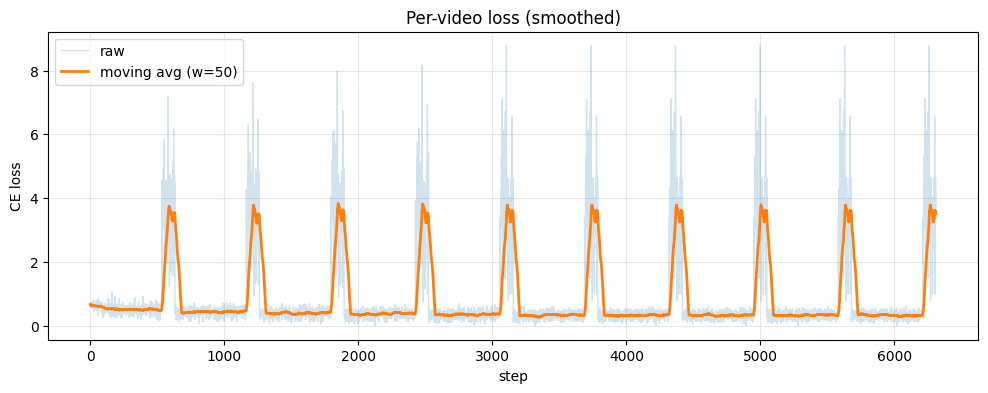

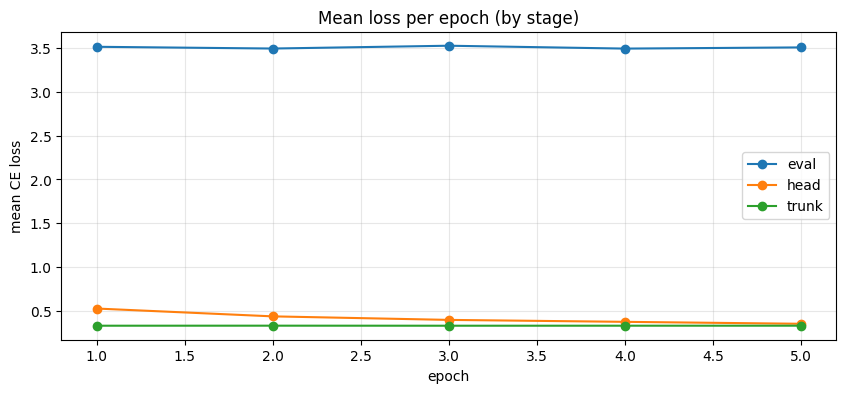

Best checkpoint: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best.pt
Best meta: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best_meta.json
Frame index: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/train_video_ids_with_frames.json


In [ ]:
# ===================== VIDVRD TRAIN + BEST + PLOTS (ONE CELL) =====================

# --------------------- MODE ---------------------
RUN = "both"          # "head" | "trunk" | "both" | "joint"
GIT_PULL = True

# If True: start a fresh run (new OUT_DIR subfolder + reset best tracking)
FRESH_RUN = True
RUN_NAME = "THEFINALONE"

# If True: build a filtered list of train videos that actually have frames (recommended)
BUILD_FRAME_INDEX = True
# ------------------------------------------------

# --------------------- PATHS ---------------------------
# Dataset is loaded from Drive zip "final_dataset_vidvrd.zip" by the loader cell below.
# It is extracted to this folder (kept outside the repo so repo refreshes won't delete it).
DATASET_ROOT = "/content/final_dataset_vidvrd/bundle_20260508_102322"
VOCAB_JSON   = "/content/drive/MyDrive/vidvrd_runs/vidvrd_vocab.json"
BASE_CKPT    = "/content/drive/MyDrive/STTran/sttran_predcls.tar"
OUT_ROOT     = "/content/drive/MyDrive/vidvrd_runs"
# -------------------------------------------------------

# --------------------- DATA SETTINGS -------------------
SPLIT         = "train"
MAX_VIDEOS    = 0          # 0 = all (but after filtering by frames index)
MAX_FRAMES    = 16         # critical for feasibility
FRAME_START   = 0
NEG_RATIO     = 2
SHUFFLE       = True
SEED          = 42
LOG_EVERY     = 50
VIDEO_IDS     = ""         # optional override: "id1,id2,..."
PROFILE_EVERY = 50         # if supported by your script

# Validation (new in trainer)
EVAL_SPLIT       = "test"  # "" disables
EVAL_MAX_VIDEOS  = 100     # 0 = all (slower)
# -------------------------------------------------------

# --------------------- CHECKPOINT / EARLY STOP --------------------
BEST_CKPT_NAME = "best.pt"
MIN_DELTA      = 0.0
PATIENCE_HEAD  = 2
PATIENCE_TRUNK = 2
SAVE_BEST_ONLY = False
# -------------------------------------------------------

# --------------------- STAGE 1 (HEAD) ------------------
EPOCHS_HEAD      = 5
OPT_HEAD         = "adamw"
LR_HEAD_1        = 5e-4
WEIGHT_DECAY_1   = 1e-4
MOMENTUM_1       = 0.9
AMP_HEAD         = True
ACCUM_STEPS_HEAD = 8
GRAD_CLIP_HEAD   = 5.0
# -------------------------------------------------------

# --------------------- STAGE 2 (TRUNK) -----------------
EPOCHS_TRUNK      = 5
OPT_TRUNK         = "adamw"
LR_HEAD_2         = 5e-5
LR_TRUNK_2        = 1e-6
WEIGHT_DECAY_2    = 1e-4
MOMENTUM_2        = 0.9
AMP_TRUNK         = False
ACCUM_STEPS_TRUNK = 8
GRAD_CLIP_TRUNK   = 0.5
# -------------------------------------------------------

# --------------------- JOINT (ONE RUN) -----------------
# Uses trainer --stage joint (optionally warms up head-only for N epochs).
JOINT_EPOCHS        = EPOCHS_HEAD + EPOCHS_TRUNK
JOINT_WARMUP_EPOCHS = EPOCHS_HEAD          # 0 disables warmup
JOINT_OPT           = OPT_TRUNK            # optimizer for the whole joint run
JOINT_LR_HEAD       = LR_HEAD_2            # stable default after head warmup
JOINT_LR_TRUNK      = LR_TRUNK_2
JOINT_WEIGHT_DECAY  = WEIGHT_DECAY_2
JOINT_MOMENTUM      = MOMENTUM_2
JOINT_AMP           = AMP_TRUNK
JOINT_ACCUM_STEPS   = ACCUM_STEPS_TRUNK
JOINT_GRAD_CLIP     = GRAD_CLIP_TRUNK
# -------------------------------------------------------

import os, subprocess, sys, json
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def sh(cmd: str):
    print("\n===== RUNNING =====\n" + cmd + "\n===================\n")
    p = subprocess.run(["bash", "-lc", cmd], text=True, capture_output=True)
    if p.stdout:
        print(p.stdout)
    if p.stderr:
        print(p.stderr, file=sys.stderr)
    if p.returncode != 0:
        raise RuntimeError(f"command failed with exit code {p.returncode}")


if GIT_PULL:
    sh("cd /content/STTran && git pull")

# Fix weight overrides (avoid stale Drive paths)
os.environ["FASTER_RCNN_AG_PTH"] = "/content/STTran/fasterRCNN/models/faster_rcnn_ag.pth"
os.environ["STTRAN_CKPT"] = BASE_CKPT

for p, label in [
    (DATASET_ROOT, "DATASET_ROOT"),
    (VOCAB_JSON, "VOCAB_JSON"),
    (BASE_CKPT, "BASE_CKPT"),
    (os.environ["FASTER_RCNN_AG_PTH"], "FASTER_RCNN_AG_PTH"),
]:
    if not os.path.exists(p):
        print(f"MISSING {label}: {p}", file=sys.stderr)
        raise SystemExit(1)

# Decide OUT_DIR
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = f"{OUT_ROOT}/{RUN_NAME}_{stamp}" if FRESH_RUN else f"{OUT_ROOT}/{RUN_NAME}"
os.makedirs(OUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUT_DIR, "losses.csv")

# Detect profile + eval support
help_txt = subprocess.check_output(
    ["bash", "-lc", "cd /content/STTran && python colab/vidvrd_train_colab.py --help"],
    text=True,
)
SUPPORTS_PROFILE = ("--profile_every" in help_txt)
SUPPORTS_EVAL = ("--eval_split" in help_txt)

# Build frame index (list of video_ids with existing frames dir)
frame_index_path = os.path.join(OUT_DIR, f"{SPLIT}_video_ids_with_frames.json")
if BUILD_FRAME_INDEX and (not VIDEO_IDS.strip()):
    root = Path(DATASET_ROOT)
    json_dir = root / f"{SPLIT}_480"
    vids = sorted(p.stem for p in json_dir.glob("*.json"))

    def resolve_frames_dir(video_id: str):
        ordered = [f"{SPLIT}_frames_480", "train_frames_480", "val_frames_480", "test_frames_480"]
        for name in ordered:
            p = root / name / video_id
            if p.is_dir():
                return str(p)
        return ""

    kept = []
    for v in vids:
        if resolve_frames_dir(v):
            kept.append(v)
    Path(frame_index_path).write_text(json.dumps({"split": SPLIT, "video_ids": kept}, indent=2) + "\n")
    print(f"[frame_index] kept {len(kept)}/{len(vids)} videos with frames -> {frame_index_path}")
    VIDEO_IDS = ",".join(kept)


def run_stage(
    stage: str,
    epochs: int,
    opt: str,
    lr_head: float,
    lr_trunk: float,
    wd: float,
    mom: float,
    amp: bool,
    accum_steps: int,
    grad_clip: float,
    patience: int,
    base_ckpt: str,
):
    flags = []
    if amp:
        flags.append("--amp")
    if SHUFFLE:
        flags.append("--shuffle_videos")
    if VIDEO_IDS.strip():
        flags.append(f'--video_ids "{VIDEO_IDS}"')
    if SUPPORTS_PROFILE and int(PROFILE_EVERY) > 0:
        flags.append(f"--profile_every {int(PROFILE_EVERY)}")
    if SAVE_BEST_ONLY:
        flags.append("--save_best_only")

    if SUPPORTS_EVAL and str(EVAL_SPLIT).strip():
        flags.append(f"--eval_split {str(EVAL_SPLIT).strip()} --eval_max_videos {int(EVAL_MAX_VIDEOS)}")

    # Trunk (and joint) stability flags
    if stage in ("trunk", "joint"):
        flags.append("--nonfinite_policy rollback_lr")
        flags.append("--lr_drop_factor 0.2 --lr_drop_min 1e-7")
        flags.append('--freeze_trunk_prefix "glocal_transformer.local_attention.layers.0.self_attn"')

    cmd = f"""
set -e
cd /content/STTran
python -u colab/vidvrd_train_colab.py \
  --out_dir \"{OUT_DIR}\" \
  --log_csv \"{CSV_PATH}\" \
  --best_ckpt_name \"{BEST_CKPT_NAME}\" \
  --min_delta {float(MIN_DELTA)} \
  --patience {int(patience)} \
  --dataset_root \"{DATASET_ROOT}\" \
  --vocab_json \"{VOCAB_JSON}\" \
  --split {SPLIT} \
  --epochs {int(epochs)} \
  --stage {stage} \
  --max_videos {int(MAX_VIDEOS)} \
  --max_frames {int(MAX_FRAMES)} \
  --frame_start {int(FRAME_START)} \
  --neg_ratio {int(NEG_RATIO)} \
  --seed {int(SEED)} \
  --log_every {int(LOG_EVERY)} \
  --accum_steps {int(accum_steps)} \
  --grad_clip {float(grad_clip)} \
  --optimizer {opt} \
  --weight_decay {float(wd)} \
  --momentum {float(mom)} \
  --lr_head {float(lr_head)} \
  --lr_trunk {float(lr_trunk)} \
  --base_ckpt \"{base_ckpt}\" \
  {" ".join(flags)}
"""
    sh(cmd)


# Joint: one trainer run (optional warmup then unfreeze)
if RUN == "joint":
    extra = []
    if SHUFFLE:
        extra.append("--shuffle_videos")
    if VIDEO_IDS.strip():
        extra.append(f'--video_ids "{VIDEO_IDS}"')
    if SUPPORTS_PROFILE and int(PROFILE_EVERY) > 0:
        extra.append(f"--profile_every {int(PROFILE_EVERY)}")
    if SAVE_BEST_ONLY:
        extra.append("--save_best_only")
    if SUPPORTS_EVAL and str(EVAL_SPLIT).strip():
        extra.append(f"--eval_split {str(EVAL_SPLIT).strip()} --eval_max_videos {int(EVAL_MAX_VIDEOS)}")

    # same stability flags as trunk
    extra.append("--nonfinite_policy rollback_lr")
    extra.append("--lr_drop_factor 0.2 --lr_drop_min 1e-7")
    extra.append('--freeze_trunk_prefix "glocal_transformer.local_attention.layers.0.self_attn"')

    cmd = f"""
set -e
cd /content/STTran
python -u colab/vidvrd_train_colab.py \
  --out_dir \"{OUT_DIR}\" \
  --log_csv \"{CSV_PATH}\" \
  --best_ckpt_name \"{BEST_CKPT_NAME}\" \
  --min_delta {float(MIN_DELTA)} \
  --patience {int(PATIENCE_TRUNK)} \
  --dataset_root \"{DATASET_ROOT}\" \
  --vocab_json \"{VOCAB_JSON}\" \
  --split {SPLIT} \
  --epochs {int(JOINT_EPOCHS)} \
  --stage joint \
  --joint_warmup_epochs {int(JOINT_WARMUP_EPOCHS)} \
  --max_videos {int(MAX_VIDEOS)} \
  --max_frames {int(MAX_FRAMES)} \
  --frame_start {int(FRAME_START)} \
  --neg_ratio {int(NEG_RATIO)} \
  --seed {int(SEED)} \
  --log_every {int(LOG_EVERY)} \
  --accum_steps {int(JOINT_ACCUM_STEPS)} \
  --grad_clip {float(JOINT_GRAD_CLIP)} \
  --optimizer {JOINT_OPT} \
  --weight_decay {float(JOINT_WEIGHT_DECAY)} \
  --momentum {float(JOINT_MOMENTUM)} \
  --lr_head {float(JOINT_LR_HEAD)} \
  --lr_trunk {float(JOINT_LR_TRUNK)} \
  --base_ckpt \"{BASE_CKPT}\" \
  {"--amp" if JOINT_AMP else ""}
""" + "\n" + " ".join(extra) + "\n"
    sh(cmd)


# Stage 1: head from BASE_CKPT
if RUN in ("head", "both"):
    run_stage(
        "head",
        EPOCHS_HEAD,
        OPT_HEAD,
        LR_HEAD_1,
        0.0,
        WEIGHT_DECAY_1,
        MOMENTUM_1,
        AMP_HEAD,
        ACCUM_STEPS_HEAD,
        GRAD_CLIP_HEAD,
        PATIENCE_HEAD,
        BASE_CKPT,
    )

# Stage 2: trunk from head best checkpoint
HEAD_BEST = os.path.join(OUT_DIR, "checkpoints", BEST_CKPT_NAME)

if RUN in ("trunk", "both"):
    if not os.path.exists(HEAD_BEST):
        raise RuntimeError(
            f"Missing head best checkpoint at {HEAD_BEST}. "
            "Run head stage first or set RUN='head'."
        )
    run_stage(
        "trunk",
        EPOCHS_TRUNK,
        OPT_TRUNK,
        LR_HEAD_2,
        LR_TRUNK_2,
        WEIGHT_DECAY_2,
        MOMENTUM_2,
        AMP_TRUNK,
        ACCUM_STEPS_TRUNK,
        GRAD_CLIP_TRUNK,
        PATIENCE_TRUNK,
        HEAD_BEST,
    )

print("Training done. Plotting from:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
df = df[df["loss"].notna()].reset_index(drop=True)
df["step"] = range(1, len(df) + 1)

# Smooth plot
w = 50
df["loss_ma"] = df["loss"].rolling(w, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(df["step"], df["loss"], alpha=0.2, linewidth=1, label="raw")
plt.plot(df["step"], df["loss_ma"], linewidth=2, label=f"moving avg (w={w})")
plt.title("Per-video loss (smoothed)")
plt.xlabel("step")
plt.ylabel("CE loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

g = df.groupby(["stage", "epoch"], as_index=False)["loss"].mean()
plt.figure(figsize=(10, 4))
for stage_name in sorted(g["stage"].unique()):
    sub = g[g["stage"] == stage_name]
    plt.plot(sub["epoch"], sub["loss"], marker="o", label=stage_name)
plt.title("Mean loss per epoch (by stage)")
plt.xlabel("epoch")
plt.ylabel("mean CE loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Best checkpoint:", os.path.join(OUT_DIR, "checkpoints", BEST_CKPT_NAME))
print("Best meta:", os.path.join(OUT_DIR, "checkpoints", "best_meta.json"))
print("Frame index:", frame_index_path if BUILD_FRAME_INDEX else "(disabled)")


[export] OUT_DIR: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352
[export] best_ckpt exists: True /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best.pt
[export] meta exists: True /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best_meta.json
[export] losses.csv exists: True /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/losses.csv
[export] copied artifacts to: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/export


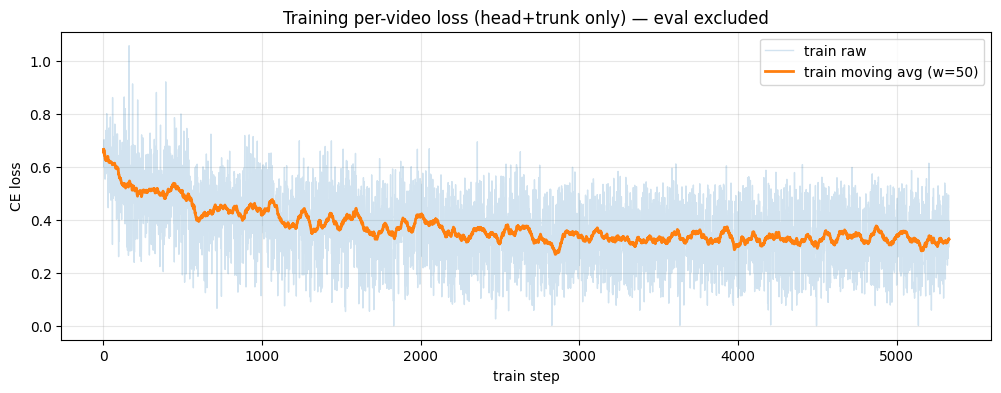

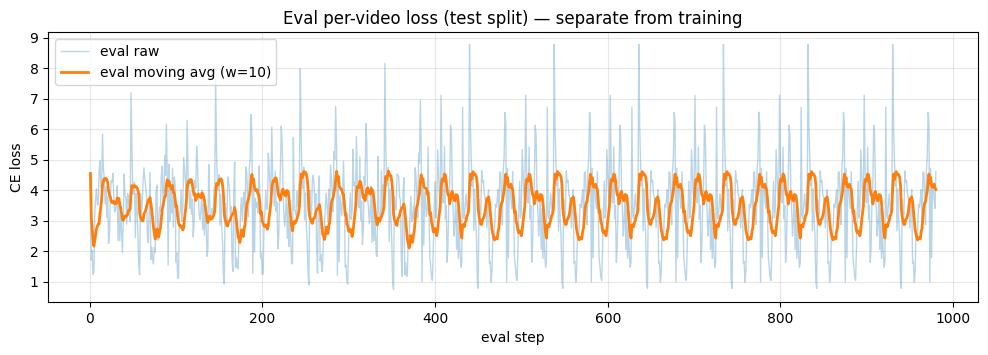

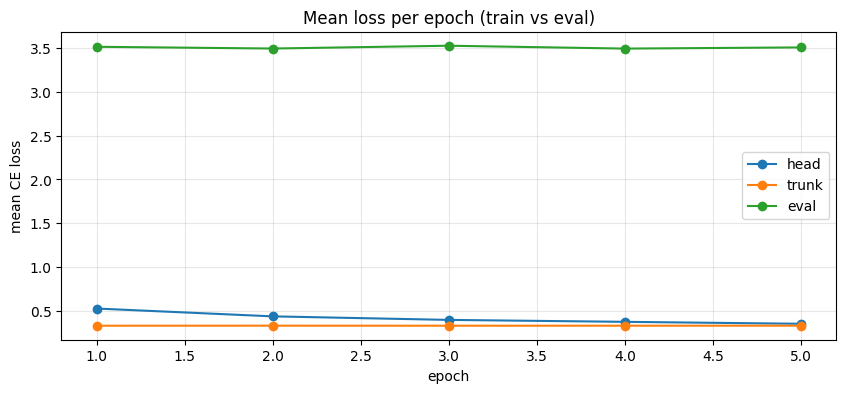

[s8] zip exists: True /content/drive/MyDrive/vidvrd-dataset_480_s8.zip
[s8] already present: /content/vidvrd-dataset_480_s8


In [ ]:
# ===================== FIXED PLOTS + EXPORT + ZIP→/content LOADER =====================
# Run this cell after training (or before runtime reset).

import os, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------- 1) Export best checkpoint + logs (safe before reset) ---------
assert 'OUT_DIR' in globals(), "OUT_DIR not found; run training cell first"
ckpt_dir = os.path.join(OUT_DIR, "checkpoints")
best_ckpt = os.path.join(ckpt_dir, BEST_CKPT_NAME)
meta_json = os.path.join(ckpt_dir, "best_meta.json")

print("[export] OUT_DIR:", OUT_DIR)
print("[export] best_ckpt exists:", os.path.exists(best_ckpt), best_ckpt)
print("[export] meta exists:", os.path.exists(meta_json), meta_json)
print("[export] losses.csv exists:", os.path.exists(CSV_PATH), CSV_PATH)

# Optional: copy best.ckpt to a stable Drive path (change if you want)
EXPORT_DIR = os.path.join(OUT_DIR, "export")
os.makedirs(EXPORT_DIR, exist_ok=True)

for src in [best_ckpt, meta_json, CSV_PATH, frame_index_path if 'frame_index_path' in globals() else None]:
    if not src:
        continue
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(EXPORT_DIR, os.path.basename(src)))

print("[export] copied artifacts to:", EXPORT_DIR)

# --------- 2) Fixed plotting: DO NOT mix eval with train per-video ---------
df = pd.read_csv(CSV_PATH)
df = df[df["loss"].notna()].reset_index(drop=True)

df_train = df[df["stage"].isin(["head", "trunk"])].copy().reset_index(drop=True)
df_eval = df[df["stage"] == "eval"].copy().reset_index(drop=True)

# Train-only per-video plot
if len(df_train):
    df_train["step"] = range(1, len(df_train) + 1)
    w = 50
    df_train["loss_ma"] = df_train["loss"].rolling(w, min_periods=1).mean()
    plt.figure(figsize=(12, 4))
    plt.plot(df_train["step"], df_train["loss"], alpha=0.2, linewidth=1, label="train raw")
    plt.plot(df_train["step"], df_train["loss_ma"], linewidth=2, label=f"train moving avg (w={w})")
    plt.title("Training per-video loss (head+trunk only) — eval excluded")
    plt.xlabel("train step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("[plot] no train rows found")

# Eval-only per-video plot (optional)
if len(df_eval):
    df_eval["step"] = range(1, len(df_eval) + 1)
    w = 10
    df_eval["loss_ma"] = df_eval["loss"].rolling(w, min_periods=1).mean()
    plt.figure(figsize=(12, 3.5))
    plt.plot(df_eval["step"], df_eval["loss"], alpha=0.3, linewidth=1, label="eval raw")
    plt.plot(df_eval["step"], df_eval["loss_ma"], linewidth=2, label=f"eval moving avg (w={w})")
    plt.title("Eval per-video loss (test split) — separate from training")
    plt.xlabel("eval step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Mean loss per epoch
m = df.groupby(["stage", "epoch"], as_index=False)["loss"].mean()
plt.figure(figsize=(10, 4))
for stage_name in ["head", "trunk", "eval"]:
    if stage_name not in set(m["stage"]):
        continue
    sub = m[m["stage"] == stage_name]
    plt.plot(sub["epoch"], sub["loss"], marker="o", label=stage_name)
plt.title("Mean loss per epoch (train vs eval)")
plt.xlabel("epoch")
plt.ylabel("mean CE loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------- 3) Drive zip → /content loader (idempotent, non-destructive) ---------
# This loads the fixed stride-8 VIDVRD dataset from Drive and extracts it locally.
# IMPORTANT:
# - We do NOT delete OUT_DIR if it already exists (so you don't lose data).
# - We only extract if the required folders are missing.
ZIP_VIDVRD = "/content/drive/MyDrive/FINALVIDVRD/final_dataset_vidvrd.zip"
OUT_VIDVRD = "/content/final_dataset_vidvrd"

print("[vidvrd] zip exists:", os.path.exists(ZIP_VIDVRD), ZIP_VIDVRD)
print("[vidvrd] out dir:", OUT_VIDVRD)

required = [
    os.path.join(OUT_VIDVRD, "train_480"),
    os.path.join(OUT_VIDVRD, "train_frames_480"),
    os.path.join(OUT_VIDVRD, "test_480"),
    os.path.join(OUT_VIDVRD, "test_frames_480"),
]

if all(os.path.isdir(p) for p in required):
    print("[vidvrd] already present (skip extract)")
else:
    import zipfile
    os.makedirs(OUT_VIDVRD, exist_ok=True)
    print("[vidvrd] extracting ->", OUT_VIDVRD)
    with zipfile.ZipFile(ZIP_VIDVRD, "r") as zf:
        zf.extractall(OUT_VIDVRD)

    # Flatten common nesting (OUT_VIDVRD/VIDVRD-DATASET_480/*)
    inner = os.path.join(OUT_VIDVRD, "VIDVRD-DATASET_480")
    if os.path.isdir(inner) and (not os.path.isdir(os.path.join(OUT_VIDVRD, "train_480"))):
        for name in os.listdir(inner):
            shutil.move(os.path.join(inner, name), os.path.join(OUT_VIDVRD, name))
        try:
            os.rmdir(inner)
        except OSError:
            pass

    for p in required:
        assert os.path.isdir(p), f"missing after extract: {p}"
    print("[vidvrd] ready:", OUT_VIDVRD)


In [ ]:
print("Train Losses (df_train):")
display(df_train.head())

In [ ]:
print("Evaluation Losses (df_eval):")
display(df_eval.head())